# Purpose

Set up a clean exploratory notebook for Chapter 4, "Dynamical System Analysis Framework".

This notebook uses the canonical surrogate ODE implementation and canonical configuration files. For now, it only performs a small RHS smoke test for the SM4 model.

# Setup and Paths

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start.resolve()
    for path in [start, *start.parents]:
        if (
            (path / "README.md").is_file()
            and (path / "src" / "config").is_dir()
            and (path / "src" / "sim" / "ode" / "model_definitions.py").is_file()
        ):
            return path
    raise RuntimeError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from src.sim.ode.model_definitions import SynchronousMachineModels

# Load Canonical Configurations

In [3]:
machine_path = PROJECT_ROOT / "src" / "config" / "params" / "machine1.yaml"
system_bus_path = PROJECT_ROOT / "src" / "config" / "params" / "system_bus.yaml"
setup_dataset_path = PROJECT_ROOT / "src" / "config" / "setup_dataset.yaml"
sm4_ic_path = PROJECT_ROOT / "src" / "config" / "ic" / "SM4" / "init_cond1.yaml"
modellings_guide_path = PROJECT_ROOT / "src" / "config" / "ic" / "modellings_guide.yaml"

machine_cfg = OmegaConf.load(machine_path)
system_bus_cfg = OmegaConf.load(system_bus_path)
setup_cfg = OmegaConf.load(setup_dataset_path)
sm4_ic_cfg = OmegaConf.load(sm4_ic_path)
modellings_guide = OmegaConf.load(modellings_guide_path)

print("Loaded canonical configuration files:")
for path in [machine_path, system_bus_path, setup_dataset_path, sm4_ic_path]:
    print(f"- {path.relative_to(PROJECT_ROOT)}")

Loaded canonical configuration files:
- src/config/params/machine1.yaml
- src/config/params/system_bus.yaml
- src/config/setup_dataset.yaml
- src/config/ic/SM4/init_cond1.yaml


In [4]:
sm4_entry = next(item for item in modellings_guide if item.get("name") == "SM4")
state_ordering = list(sm4_entry.get("keys"))
auxiliary_variables = list(sm4_entry.get("keys_ext"))
state_names = state_ordering

print("Configuration summary")
print(f"model flag: SM4")
print(f"machine number: 1")
print(f"SM4 state ordering: {state_ordering}")
print(f"auxiliary fixed-bus variables: {auxiliary_variables}")
print(f"machine parameters loaded: {list(machine_cfg.keys())}")
print(f"system bus parameters loaded: {list(system_bus_cfg.keys())}")
print(f"dataset time horizon: {setup_cfg.time}")
print(f"dataset number of points: {setup_cfg.num_of_points}")

Configuration summary
model flag: SM4
machine number: 1
SM4 state ordering: ['theta', 'omega', 'E_d_dash', 'E_q_dash']
auxiliary fixed-bus variables: ['Vs', 'theta_vs']
machine parameters loaded: ['D', 'E_fd', 'H', 'P_m', 'T_d_dash', 'T_q_dash', 'X_d', 'X_d_dash', 'X_q', 'X_q_dash', 'X_d_dash_dash', 'T_d_dash_dash', 'X_q_dash_dash', 'T_q_dash_dash']
system bus parameters loaded: ['omega_B', 'Rs', 'Re', 'Xep']
dataset time horizon: 1.0
dataset number of points: 1000


# Instantiate Canonical SM4 Model

In [5]:
model_cfg = OmegaConf.create(OmegaConf.to_container(setup_cfg, resolve=False))
model_cfg.model.model_flag = "SM4"
model_cfg.model.machine_num = 1
model_cfg.PINN_flag = False
model_cfg.dirs.params_dir = str(PROJECT_ROOT / "src" / "config" / "params")

sm4_model = SynchronousMachineModels(model_cfg)

print("Instantiated canonical SM4 model.")

Instantiated canonical SM4 model.


# RHS Smoke Test

In [6]:
x_smoke = np.array([0.5, 0.0, 0.0, 1.0, 1.0, 0.0], dtype=float)
rhs = np.asarray(sm4_model.odequations(0.0, x_smoke), dtype=float)

print(f"input vector [theta, omega, E_d_dash, E_q_dash, Vs, theta_vs]: {x_smoke}")
print(f"RHS output: {rhs}")
print(f"output length: {len(rhs)}")
print(f"output shape: {rhs.shape}")

assert rhs.shape == (6,)
print("Success: canonical SM4 RHS smoke test completed.")

input vector [theta, omega, E_d_dash, E_q_dash, Vs, theta_vs]: [0.5 0.  0.  1.  1.  0. ]
RHS output: [ 0.         -1.76233635  0.          0.00645225  0.          0.        ]
output length: 6
output shape: (6,)
Success: canonical SM4 RHS smoke test completed.


# Local SM4 Analysis Representation

The surrogate framework operates on the augmented canonical representation `[theta, omega, E_d_dash, E_q_dash, Vs, theta_vs]`.

For the Chapter 4 local dynamical-system analysis, we use the reduced local state `[theta, omega, E_d_dash, E_q_dash]` and treat `Vs` and `theta_vs` as fixed-bus operating-condition parameters.

Both representations use the same underlying canonical model equations from `SynchronousMachineModels`.

In [7]:
Vs = 1.0
theta_vs = 0.0

def rhs_sm4_local(t, x4):
    x_aug = np.asarray([*x4, Vs, theta_vs], dtype=float)
    return np.asarray(sm4_model.odequations(t, x_aug), dtype=float)[:4]

In [8]:
x4_smoke = np.array([0.5, 0.0, 0.0, 1.0], dtype=float)
dx4 = rhs_sm4_local(0.0, x4_smoke)

x_aug_smoke = np.asarray([*x4_smoke, Vs, theta_vs], dtype=float)
dx_aug = np.asarray(sm4_model.odequations(0.0, x_aug_smoke), dtype=float)

print(f"input x4 [theta, omega, E_d_dash, E_q_dash]: {x4_smoke}")
print(f"reduced derivative output: {dx4}")
print(f"reduced output shape: {dx4.shape}")
print(f"full canonical 6-state derivative: {dx_aug}")
print(f"dVs/dt: {dx_aug[4]}")
print(f"dtheta_vs/dt: {dx_aug[5]}")

input x4 [theta, omega, E_d_dash, E_q_dash]: [0.5 0.  0.  1. ]
reduced derivative output: [ 0.         -1.76233635  0.          0.00645225]
reduced output shape: (4,)
full canonical 6-state derivative: [ 0.         -1.76233635  0.          0.00645225  0.          0.        ]
dVs/dt: 0.0
dtheta_vs/dt: 0.0


# Equilibrium Operating Point

`x*` is used as the local reference operating point for the Chapter 4 dynamical-system analysis.

This is a local analysis equilibrium, not the broad initial-condition distribution used for surrogate training.

In [9]:
from scipy.integrate import solve_ivp
from scipy.optimize import root

x_guess = np.array([0.5, 0.0, 0.0, 1.0], dtype=float)
t_end_relax = 100.0
t_eval_relax = np.linspace(0.0, t_end_relax, 10001)

sol_relax = solve_ivp(
    rhs_sm4_local,
    (0.0, t_end_relax),
    x_guess,
    t_eval=t_eval_relax,
    rtol=1e-8,
    atol=1e-10,
)

if not sol_relax.success:
    raise RuntimeError(f"Relaxation solve failed: {sol_relax.message}")

x_star_relaxed = sol_relax.y[:, -1]
root_result = root(lambda x: rhs_sm4_local(0.0, x), x_star_relaxed)

if root_result.success:
    x_star = root_result.x
else:
    x_star = x_star_relaxed
    print(f"Warning: root refinement failed; using relaxed state. Message: {root_result.message}")

residual = rhs_sm4_local(0.0, x_star)
residual_norm = np.linalg.norm(residual)

print(f"root refinement succeeded: {root_result.success}")
print(f"x_star: {x_star}")
print(f"rhs_sm4_local(0.0, x_star): {residual}")
print(f"residual norm ||f(x*)||: {residual_norm:.6e}")

root refinement succeeded: True
x_star: [ 3.36032747e-01  3.10756973e-24 -5.22407492e-35  1.05904835e+00]
rhs_sm4_local(0.0, x_star): [3.10756973e-24 8.87551090e-16 1.68518546e-34 0.00000000e+00]
residual norm ||f(x*)||: 8.875511e-16


In [10]:
theta_star, omega_star, E_d_star, E_q_star = x_star
I_d_star, I_q_star = sm4_model.calculate_currents(
    theta_star,
    E_d_star,
    E_q_star,
    Vs,
    theta_vs,
)

P_m = float(sm4_model.P_m)
P_e_star = float(
    E_d_star * I_d_star
    + E_q_star * I_q_star
    + (sm4_model.X_q_dash - sm4_model.X_d_dash) * I_q_star * I_d_star
)

print(f"P_m: {P_m:.12f}")
print(f"P_e(x*): {P_e_star:.12f}")
print(f"P_m - P_e(x*): {P_m - P_e_star:.6e}")

P_m: 0.710000000000
P_e(x*): 0.710000000000
P_m - P_e(x*): 1.110223e-16


# Perturbed Ringdown Trajectory

The perturbation excites the local dynamics around `x_star`.

The resulting trajectory is a ringdown response. It will later be used to connect observable decay behaviour to local dynamical characteristics.

In [11]:
delta_x = np.array([0.01, 0.0, 0.0, 0.0], dtype=float)
x0_ringdown = x_star + delta_x

t_end_ringdown = 20.0
n_ringdown = 5000
t_eval_ringdown = np.linspace(0.0, t_end_ringdown, n_ringdown + 1)

sol_ringdown = solve_ivp(
    rhs_sm4_local,
    (0.0, t_end_ringdown),
    x0_ringdown,
    t_eval=t_eval_ringdown,
    rtol=1e-8,
    atol=1e-10,
)

if not sol_ringdown.success:
    raise RuntimeError(f"Ringdown solve failed: {sol_ringdown.message}")

ringdown_deviation = sol_ringdown.y - x_star[:, None]
final_state = sol_ringdown.y[:, -1]
final_deviation = final_state - x_star
max_abs_deviation = np.max(np.abs(ringdown_deviation), axis=1)

print(f"perturbation vector: {delta_x}")
print(f"x0_ringdown: {x0_ringdown}")
print(f"final state: {final_state}")
print(f"final deviation from x_star: {final_deviation}")
print(f"max absolute deviation per state: {max_abs_deviation}")

perturbation vector: [0.01 0.   0.   0.  ]
x0_ringdown: [ 3.46032747e-01  3.10756973e-24 -5.22407492e-35  1.05904835e+00]
final state: [ 3.36035580e-01 -3.66838789e-07 -5.04286612e-63  1.05904156e+00]
final deviation from x_star: [ 2.83353344e-06 -3.66838789e-07  5.22407492e-35 -6.79086231e-06]
max absolute deviation per state: [1.00000000e-02 7.64794955e-03 5.22407492e-35 5.64684639e-05]


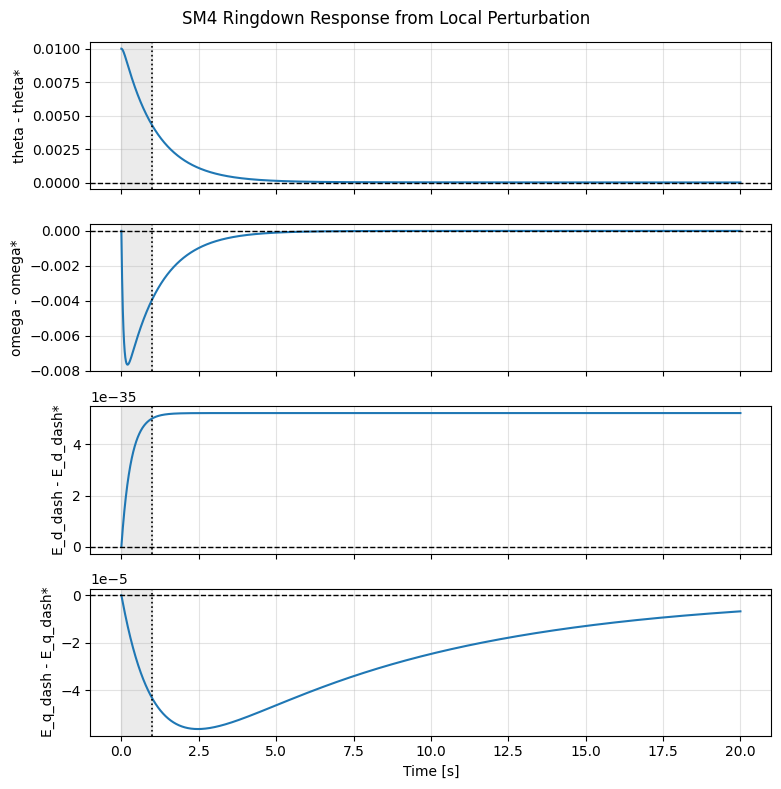

In [12]:
deviation_labels = [
    "theta - theta*",
    "omega - omega*",
    "E_d_dash - E_d_dash*",
    "E_q_dash - E_q_dash*",
]
surrogate_horizon = float(setup_cfg.time)

fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
for idx, (ax, label) in enumerate(zip(axes, deviation_labels)):
    ax.plot(sol_ringdown.t, ringdown_deviation[idx], linewidth=1.5)
    ax.axvspan(0.0, surrogate_horizon, color="tab:gray", alpha=0.15)
    ax.axvline(surrogate_horizon, color="black", linestyle=":", linewidth=1.2)
    ax.axhline(0.0, linestyle="--", color="black", linewidth=1.0)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.35)

# axes[0].text(
#     surrogate_horizon,
#     0.95,
#     "1 s surrogate horizon",
#     transform=axes[0].get_xaxis_transform(),
#     ha="right",
#     va="top",
#     fontsize=9,
# )
axes[-1].set_xlabel("Time [s]")
fig.suptitle("SM4 Ringdown Response from Local Perturbation")
fig.tight_layout()
plt.show()

# Local Linearisation and Eigenvalue Analysis

Local eigenvalues show which modes exist near `x_star`.

Here the eigenvalues are real, so the local response is non-oscillatory. The printed time constants indicate the slow and fast modes that can contribute to the ringdown.

In [13]:
def numerical_jacobian(f, x0, eps=1e-6):
    x0 = np.asarray(x0, dtype=float)
    n = x0.size
    A = np.zeros((n, n), dtype=float)

    for idx in range(n):
        h = eps * max(1.0, abs(x0[idx]))
        dx = np.zeros(n, dtype=float)
        dx[idx] = h
        A[:, idx] = (f(x0 + dx) - f(x0 - dx)) / (2.0 * h)

    return A


A = numerical_jacobian(lambda x: rhs_sm4_local(0.0, x), x_star, eps=1e-6)
eigvals, eigvecs = np.linalg.eig(A)

sort_idx = np.argsort(np.real(eigvals))[::-1]
eigvals = eigvals[sort_idx]
eigvecs = eigvecs[:, sort_idx]

print("Jacobian A:")
print(A)
print("\nEigenvalues sorted by real part, closest to zero first:")
for idx, lam in enumerate(eigvals, start=1):
    real_part = float(np.real(lam))
    imag_part = float(np.imag(lam))
    tau = -1.0 / real_part if real_part < 0 else np.inf
    freq_hz = abs(imag_part) / (2.0 * np.pi)
    print(
        f"mode {idx}: lambda = {real_part:+.8e} {imag_part:+.8e}j | "
        f"tau = {tau:.6e} s | f = {freq_hz:.6e} Hz"
    )

Jacobian A:
[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.36194801e+01 -1.57079633e+01  1.26444073e+01 -4.84118524e+00]
 [ 0.00000000e+00  0.00000000e+00 -3.22580645e+00  0.00000000e+00]
 [-6.70630519e-03  0.00000000e+00 -1.03819334e-04 -1.32242275e-01]]

Eigenvalues sorted by real part, closest to zero first:
mode 1: lambda = -1.29444149e-01 +0.00000000e+00j | tau = 7.725340e+00 s | f = 0.000000e+00 Hz
mode 2: lambda = -9.24007450e-01 +0.00000000e+00j | tau = 1.082242e+00 s | f = 0.000000e+00 Hz
mode 3: lambda = -3.22580645e+00 +0.00000000e+00j | tau = 3.100000e-01 s | f = 0.000000e+00 Hz
mode 4: lambda = -1.47867539e+01 +0.00000000e+00j | tau = 6.762809e-02 s | f = 0.000000e+00 Hz


## Modal Time Scales and State Contributions

The spread in time constants indicates multiple local time scales.

Normalized eigenvector components indicate which states dominate each mode. Together, these quantities help interpret which dynamics appear in the ringdown trajectory.

In [14]:
modal_taus = np.array([
    -1.0 / np.real(lam) if np.real(lam) < 0 else np.nan
    for lam in eigvals
])
stable_taus = modal_taus[np.isfinite(modal_taus) & (modal_taus > 0.0)]
tau_slowest = float(np.max(stable_taus))
tau_fastest = float(np.min(stable_taus))
time_scale_ratio = tau_slowest / tau_fastest

eigvec_abs = np.abs(eigvecs)
state_contributions = (eigvec_abs / np.maximum(eigvec_abs.max(axis=0, keepdims=True), 1e-12)).T

print("Modal table:")
header = (
    f"{'mode':>4} {'Re(lambda)':>14} {'Im(lambda)':>14} {'tau [s]':>12} "
    f"{'theta':>10} {'omega':>10} {'E_d_dash':>10} {'E_q_dash':>10}"
)
print(header)
for idx, lam in enumerate(eigvals, start=1):
    contrib = state_contributions[idx - 1]
    print(
        f"{idx:4d} {np.real(lam):14.6e} {np.imag(lam):14.6e} {modal_taus[idx - 1]:12.6e} "
        f"{contrib[0]:10.3f} {contrib[1]:10.3f} {contrib[2]:10.3f} {contrib[3]:10.3f}"
    )

print(f"\ntau_slowest: {tau_slowest:.6e} s")
print(f"tau_fastest: {tau_fastest:.6e} s")
print(f"time-scale ratio tau_slowest/tau_fastest: {time_scale_ratio:.6e}")

Modal table:
mode     Re(lambda)     Im(lambda)      tau [s]      theta      omega   E_d_dash   E_q_dash
   1  -1.294441e-01   0.000000e+00 7.725340e+00      0.417      0.054      0.000      1.000
   2  -9.240074e-01   0.000000e+00 1.082242e+00      1.000      0.924      0.000      0.008
   3  -3.225806e+00   0.000000e+00 3.100000e-01      0.310      1.000      0.653      0.001
   4  -1.478675e+01   0.000000e+00 6.762809e-02      0.068      1.000      0.000      0.000

tau_slowest: 7.725340e+00 s
tau_fastest: 6.762809e-02 s
time-scale ratio tau_slowest/tau_fastest: 1.142327e+02


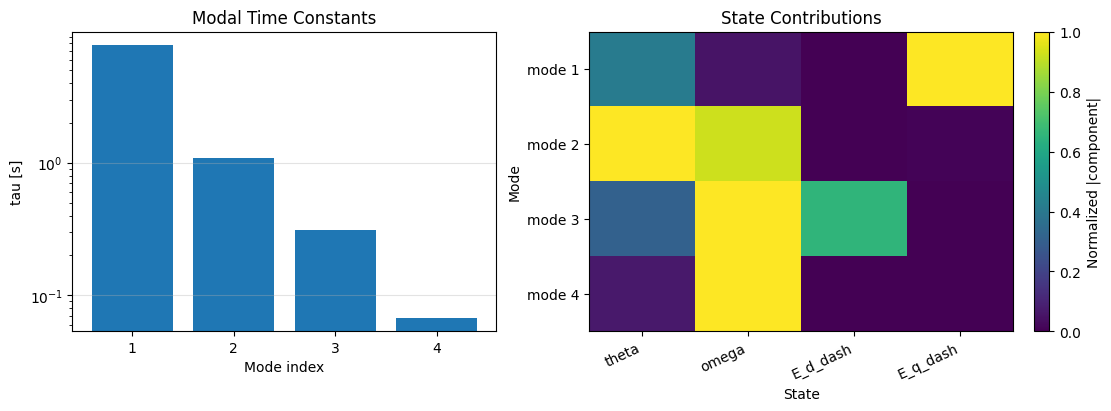

In [15]:
mode_indices = np.arange(1, len(eigvals) + 1)

fig, (ax_tau, ax_heat) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax_tau.bar(mode_indices, modal_taus)
ax_tau.set_yscale("log")
ax_tau.set_xlabel("Mode index")
ax_tau.set_ylabel("tau [s]")
ax_tau.set_title("Modal Time Constants")
ax_tau.set_xticks(mode_indices)
ax_tau.grid(True, axis="y", alpha=0.35)

image = ax_heat.imshow(state_contributions, aspect="auto")
fig.colorbar(image, ax=ax_heat, label="Normalized |component|")
ax_heat.set_xticks(np.arange(len(state_names)))
ax_heat.set_xticklabels(state_names, rotation=25, ha="right")
ax_heat.set_yticks(np.arange(len(eigvals)))
ax_heat.set_yticklabels([f"mode {idx}" for idx in mode_indices])
ax_heat.set_xlabel("State")
ax_heat.set_ylabel("Mode")
ax_heat.set_title("State Contributions")

plt.show()

# Observable Decay Behaviour

Trajectory decay shows what behaviour is observable in the simulated response.

The fitted trajectory decay and the slowest modal time constant need not match exactly, because a measured trajectory can contain a mixture of local modes. The 1-second surrogate horizon only observes the beginning of the slow response.

In [16]:
X_dev = sol_ringdown.y - x_star[:, None]
dtheta = X_dev[0, :]
t_ring = sol_ringdown.t

abs_dtheta = np.abs(dtheta)
fit_mask = abs_dtheta > 1e-6

if np.count_nonzero(fit_mask) < 2:
    tau_fit = np.nan
    fit_slope = np.nan
    fit_intercept = np.nan
else:
    fit_slope, fit_intercept = np.polyfit(t_ring[fit_mask], np.log(abs_dtheta[fit_mask]), 1)
    tau_fit = -1.0 / fit_slope if fit_slope < 0 else np.nan

slowest_linear_tau = tau_slowest
relative_tau_difference = (
    abs(tau_fit - slowest_linear_tau) / slowest_linear_tau
    if np.isfinite(tau_fit) and np.isfinite(slowest_linear_tau)
    else np.nan
)

print(f"fitted theta decay tau: {tau_fit:.6e} s")
print(f"slowest modal tau: {slowest_linear_tau:.6e} s")
print(f"relative difference: {relative_tau_difference:.6e}")
print("Note: the fitted trajectory decay reflects visible mixed-mode behaviour, not necessarily the slowest modal time constant.")

fitted theta decay tau: 2.719750e+00 s
slowest modal tau: 7.725340e+00 s
relative difference: 6.479443e-01
Note: the fitted trajectory decay reflects visible mixed-mode behaviour, not necessarily the slowest modal time constant.


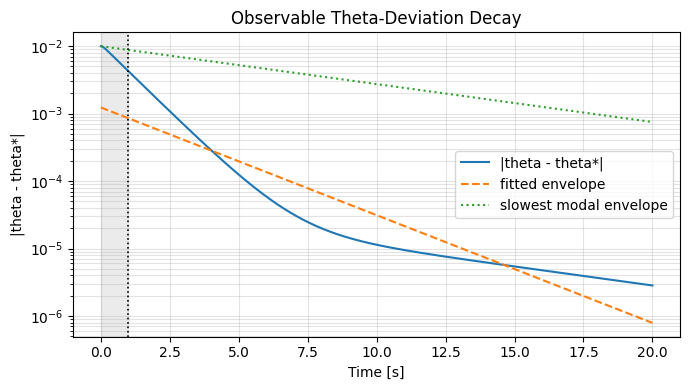

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(t_ring, abs_dtheta, label="|theta - theta*|")

if np.isfinite(tau_fit):
    fitted_envelope = np.exp(fit_slope * t_ring[fit_mask] + fit_intercept)
    ax.semilogy(t_ring[fit_mask], fitted_envelope, linestyle="--", label="fitted envelope")

if np.isfinite(slowest_linear_tau):
    slow_modal_envelope = abs_dtheta[0] * np.exp(-t_ring / slowest_linear_tau)
    ax.semilogy(t_ring, slow_modal_envelope, linestyle=":", label="slowest modal envelope")

ax.axvspan(0.0, surrogate_horizon, color="tab:gray", alpha=0.15)
ax.axvline(surrogate_horizon, color="black", linestyle=":", linewidth=1.2)
ax.set_xlabel("Time [s]")
ax.set_ylabel("|theta - theta*|")
ax.set_title("Observable Theta-Deviation Decay")
ax.grid(True, which="both", alpha=0.35)
ax.legend()
fig.tight_layout()
plt.show()

# Notes and Next Steps

- The notebook now contains the core Chapter 4 illustrative workflow for one canonical SM4 example.
- Remaining thesis-production work: add a workflow schematic and controlled result export once the figure set is finalized.
- No surrogate prediction, result exporting, or script refactor is included yet.